# Install necessary packages

In [1]:
# @title
# Update git annex version that is compatible with datalad
!wget -O- http://neuro.debian.net/lists/bionic.us-nh.full | tee /etc/apt/sources.list.d/neurodebian.sources.list \
 && export GNUPGHOME="$(mktemp -d)" \
 && echo "disable-ipv6" >> ${GNUPGHOME}/dirmngr.conf \
 && (apt-key adv --homedir $GNUPGHOME --recv-keys --keyserver hkp://pgpkeys.eu 0xA5D32F012649A5A9 \
|| { curl -sSL http://neuro.debian.net/_static/neuro.debian.net.asc | apt-key add -; } ) \
 && apt-get update \
 && apt-get install git-annex-standalone git
!git config --global user.name "mo"
!git config --global user.email "myatmo@outlook.com"
# Install datalad
!pip install datalad


--2024-10-30 16:10:49--  http://neuro.debian.net/lists/bionic.us-nh.full
Resolving neuro.debian.net (neuro.debian.net)... 129.170.233.11
Connecting to neuro.debian.net (neuro.debian.net)|129.170.233.11|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262
Saving to: ‘STDOUT’

-                   100%[===================>]     262  --.-KB/s    in 0s      

deb http://neuro.debian.net/debian data main contrib non-free
#deb-src http://neuro.debian.net/debian data main contrib non-free
deb http://neuro.debian.net/debian bionic main contrib non-free
#deb-src http://neuro.debian.net/debian bionic main contrib non-free
2024-10-30 16:10:49 (41.4 MB/s) - written to stdout [262/262]

Executing: /tmp/apt-key-gpghome.avYLzqJskE/gpg.1.sh --homedir /tmp/tmp.vwQDa5lWV1 --recv-keys --keyserver hkp://pgpkeys.eu 0xA5D32F012649A5A9
gpg: key A5D32F012649A5A9: "NeuroDebian Archive Key <pkg-exppsy-maintainers@lists.alioth.debian.org>" not changed
gpg: Total number processed: 1
gpg:   

In [1]:
# make sure skimage version is 0.19.2
!pip install scikit-image==0.19.2

# Mounting Google Drive

In [2]:
# Mounting google drive to access data
from google.colab import drive
drive.mount('/content/drive')

# change the current working directory to the (desired) directory
%cd drive/MyDrive/I2K_workshop

Mounted at /content/drive
/content/drive/MyDrive/I2K_workshop


In [27]:
# @title
# Only need to run this once
#!datalad clone https://github.com/tp81/umii-fatchecker-dataset.git

Cloning:   0% 0.00/2.00 [00:00<?, ? candidates/s]
Enumerating: 0.00 Objects [00:00, ? Objects/s]
                                              
Counting:   0% 0.00/41.1k [00:00<?, ? Objects/s]
                                                
Compressing:   0% 0.00/32.0k [00:00<?, ? Objects/s]
                                                   
Receiving:   0% 0.00/41.1k [00:00<?, ? Objects/s]
Receiving:   7% 2.88k/41.1k [00:00<00:01, 27.8k Objects/s]
Receiving:  21% 8.64k/41.1k [00:00<00:00, 43.9k Objects/s]
Receiving:  41% 16.9k/41.1k [00:00<00:00, 59.6k Objects/s]
Receiving:  74% 30.4k/41.1k [00:00<00:00, 88.5k Objects/s]
                                                          
Resolving:   0% 0.00/9.39k [00:00<?, ? Deltas/s]
Resolving:  63% 5.92k/9.39k [00:00<00:00, 58.7k Deltas/s]
[INFO   ] Detected a filesystem without fifo support.
|   Disabling ssh connection caching. 
[INFO   ] Remote origin not usable by git-annex; setting annex-ignore 
[INFO   ] https://github.com/tp81/umii

# Import libraires

In [3]:
#import datalad.api as dl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import sys
import glob
import math
import skimage.io as skio
import skimage
import json
import plotly.express as px
import pandas as pd
import numpy as np
import random


# Data Organization

In [4]:
# given the file name, visualize the images and masks
def visualize_image(filename):
    img = skio.imread(filename) # read image
    plt.imshow(img, cmap='gray') # show the image
    plt.show()


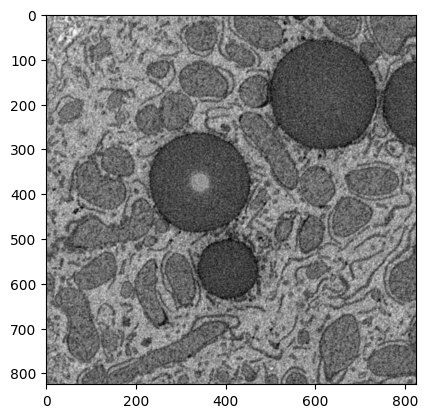

In [10]:
visualize_image("data/images/50494616.jpg")

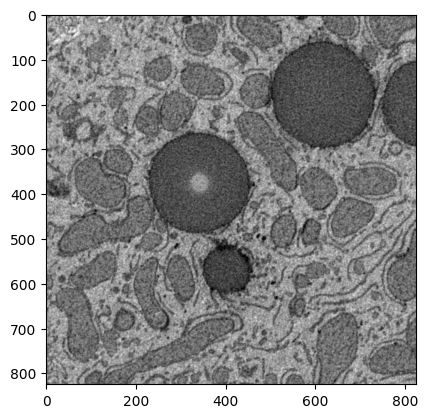

In [5]:
visualize_image("data/images/50494617.jpg")

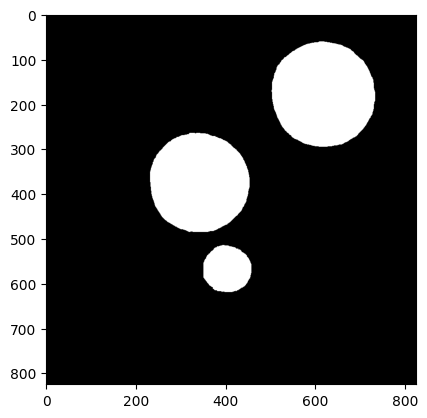

In [6]:
visualize_image("data/masks/50494617.png")

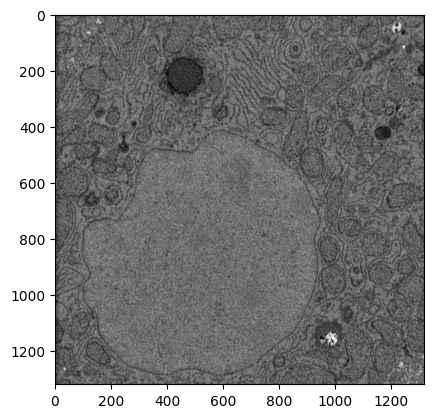

In [7]:
visualize_image("data/images/50494628.jpg")

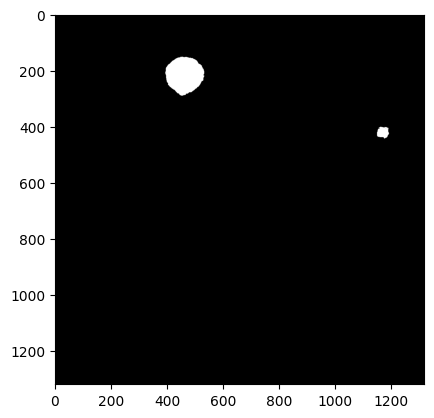

In [8]:
visualize_image("data/masks/50494628.png")

In [9]:
data_root = 'data/'

# get all the file path name
image_file_list = glob.glob(os.path.join(data_root, 'images') + '/*jpg')
mask_file_list = glob.glob(os.path.join(data_root, 'masks') + '/*png')

# sort the file name
image_file_list.sort()
mask_file_list.sort()

In [11]:
image_file_list[:5]

['data/images/50494616.jpg',
 'data/images/50494617.jpg',
 'data/images/50494618.jpg',
 'data/images/50494619.jpg',
 'data/images/50494620.jpg']

In [12]:
mask_file_list[:5]

['data/masks/50494616.png',
 'data/masks/50494617.png',
 'data/masks/50494618.png',
 'data/masks/50494619.png',
 'data/masks/50494620.png']

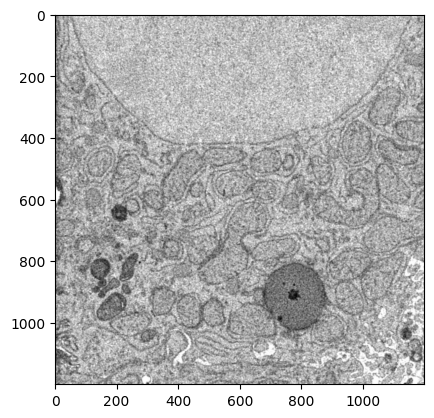

In [13]:
visualize_image(image_file_list[530])

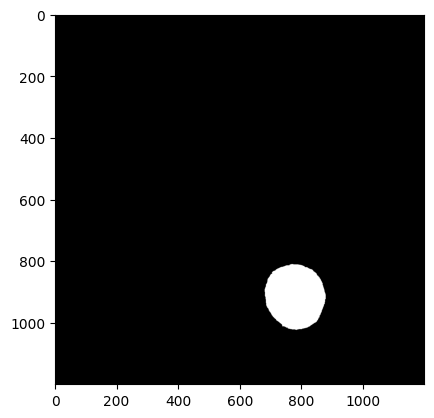

In [18]:
visualize_image(mask_file_list[530])

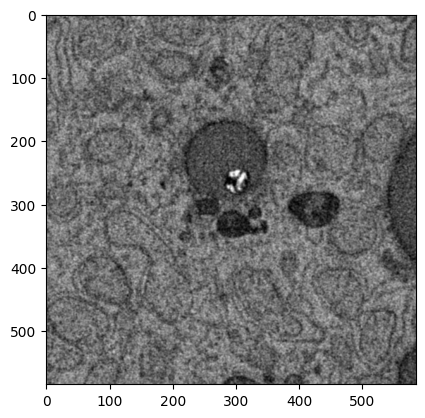

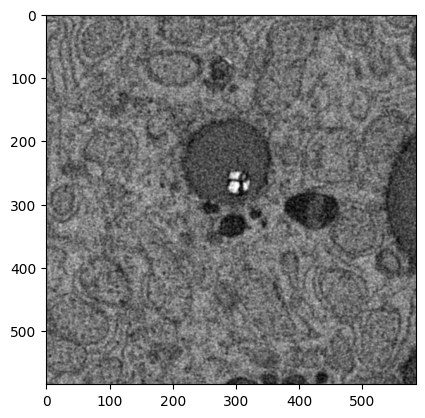

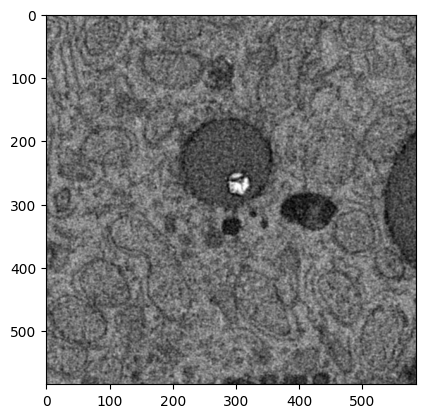

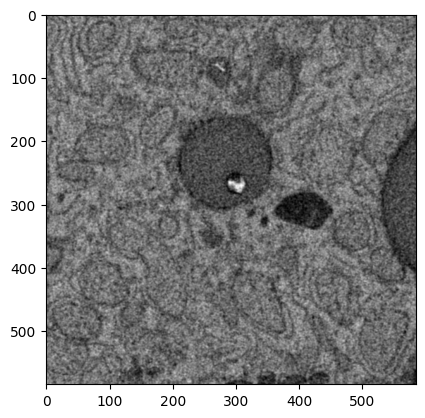

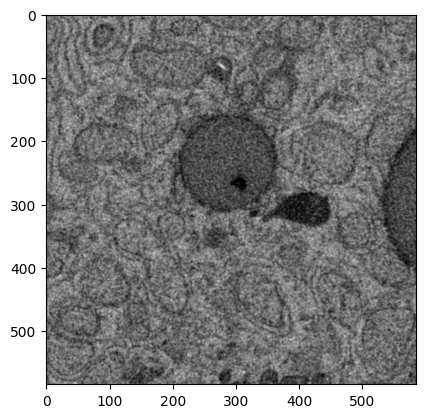

In [15]:
for i in range(10, 15):
    visualize_image(image_file_list[i])


# Data Integrity

In [14]:
# check the total number of files in images and masks
print("number of images: ", len(image_file_list))
print("number of masked images: ", len(mask_file_list))

number of images:  2341
number of masked images:  2341


## Missing Data and Duplicates

In [154]:
# check all the images have corresponding images and masks
for i in range(len(image_file_list)):
    img_name = os.path.basename(image_file_list[i]).strip('.jpg') # get the name of image file
    mask_name = os.path.basename(mask_file_list[i]).strip('.png') # get the name of mask file
    # assert imagefile name and mask file name are the same
    if img_name != mask_name:
        print(f"File mismatch found at: {i} image name: {img_name}, mask name: {mask_name}")
    continue



File mismatch found at: 2334 image name: 56482836, mask name: 56482836 (1)
File mismatch found at: 2335 image name: 56482844, mask name: 56482836
File mismatch found at: 2336 image name: 56482856, mask name: 56482844 (1)
File mismatch found at: 2337 image name: 56482864, mask name: 56482844
File mismatch found at: 2338 image name: 56482869, mask name: 56482856 (1)
File mismatch found at: 2339 image name: 56482877, mask name: 56482856
File mismatch found at: 2340 image name: 56482878, mask name: 56482864


In [157]:
# remove duplicate mask files
for i in range(len(mask_file_list)):
    mask_name = os.path.basename(mask_file_list[i]).strip('.png')
    if mask_name.find('(1)') != -1: # look for duplicate files that have (1) in file name
        print(i, mask_name)
        os.remove(mask_file_list[i]) # delete the duplicate file


2334 56482836 (1)
2336 56482844 (1)
2338 56482856 (1)


In [15]:
# check again if the total number of files in images and masks are the same
# remember to load all the files with glob again
data_root = 'data/'

# get all the file path name
image_file_list = glob.glob(os.path.join(data_root, 'images') + '/*jpg')
mask_file_list = glob.glob(os.path.join(data_root, 'masks') + '/*png')

# sort the file name
image_file_list.sort()
mask_file_list.sort()

print("number of images: ", len(image_file_list))
print("number of masked images: ", len(mask_file_list))

number of images:  2341
number of masked images:  2341


# Consistent Image Dimensions and Corrupted Files

In [16]:
# first image, mask pair dimensions
img = skio.imread(image_file_list[0])
print(f"Image shape: {img.shape}")

mask = skio.imread(mask_file_list[0])
print(f"Mask shape: {mask.shape}")



Image shape: (825, 825, 3)
Mask shape: (825, 825)


In [17]:
# check for corrupted files and check all images and masks pair have same dimension
# also get the range of dimensions
smallest = math.inf
largest = 0

for i in range(len(image_file_list[0:10])):
    # check if image file is corrupted
    try:
        img = skio.imread(image_file_list[i])
    except:
        print(f"Invalid image file at: {i}")

    # check if mask file is corrupted
    try:
        mask = skio.imread(mask_file_list[i])
    except:
        print(f"Invalid mask file at: {i}")

    # get the samllest and largest dimensions
    if img.shape[0] < smallest:
        smallest = img.shape[0]
    if img.shape[0] > largest:
        largest = img.shape[0]

    # make sure image and mask pair has same dimension
    assert img.shape[:2] == mask.shape, "Mismatch Dimension Found!"


print(f"Smallest dimension: {smallest}")
print(f"Largest dimension: {largest}")

Smallest dimension: 825
Largest dimension: 1319


## Checking Intensity Range

In [18]:
# get the first pair of image and mask pixel intensity range
img = skio.imread(image_file_list[0])
print(f"Image pixel intensity range: ({img.min()} , {img.max()})")

mask = skio.imread(mask_file_list[0])
print(f"Mask pixel intensity range: ({mask.min()} , {mask.max()})")


Image pixel intensity range: (0 , 255)
Mask pixel intensity range: (0 , 1)


In [19]:
# check image intensity range is (0, 255), and mask internsity range is (0, 1)
for i in range(len(image_file_list[0:10])):
    img = skio.imread(image_file_list[i])
    if img.min() < 0 or img.max() > 255:
        print(f"Unexpected intensity range at {i}")

    mask = skio.imread(mask_file_list[i])
    if mask.min() < 0 or mask.max() > 1:
        print(f"Unexpected intensity range at {i}")

# Data splitting

In [20]:
# visualize two images side by side and two mask images
# inputs n1, n2: indices of images and masks
def show_image_pairs(n1, n2):
    img1 = mpimg.imread(image_file_list[n1])
    img2 = mpimg.imread(image_file_list[n2])
    mask1 = mpimg.imread(mask_file_list[n1])
    mask2 = mpimg.imread(mask_file_list[n2])
    fig, ax = plt.subplots(nrows=2, ncols=2)
    ax[0][0].imshow(img1, cmap='gray')
    ax[0][1].imshow(img2, cmap='gray')
    ax[1][0].imshow(mask1, cmap='gray')
    ax[1][1].imshow(mask2, cmap='gray')
    plt.show()


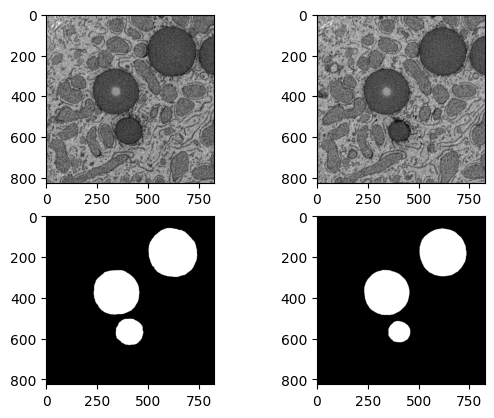

In [21]:
show_image_pairs(0, 1)

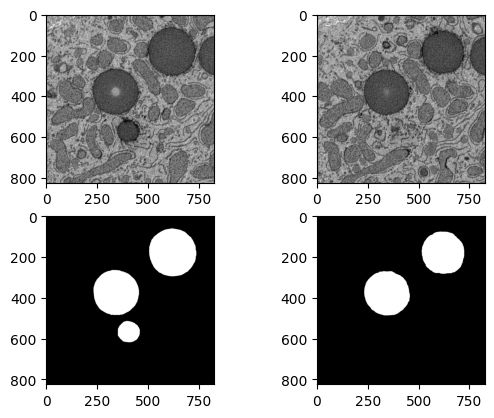

In [8]:
show_image_pairs(1, 5)

## Normalized Mutual Information

In [23]:
# calculate normalized mutual information between 2 images
# input: file names of two images and target_size of images to be resized
# return: float value; the higher the value the more similar the two images are

def calculate_nmi(file1, file2, target_size=(256,256,3)):
    img1 = skio.imread(file1) # load the first image file
    img2 = skio.imread(file2) # load the second image file

    # resize images to the given target_size; default is 256x256
    img1_scaled = skimage.transform.resize(img1, target_size)
    img2_scaled = skimage.transform.resize(img2, target_size)

    # calculate normalized mutual value between 2 images
    nmi = skimage.metrics.normalized_mutual_information(img1_scaled, img2_scaled)
    return nmi


In [10]:
# normalized mutual information between the first image and itself
print(calculate_nmi(image_file_list[0], image_file_list[0]))
print(calculate_nmi(mask_file_list[0], mask_file_list[0]))


1.9999999999999996
1.9999999999999996


In [12]:
# normalized mutual information between the first image and second image
print(calculate_nmi(image_file_list[0], image_file_list[1]))
print(calculate_nmi(mask_file_list[0], mask_file_list[1]))


1.0400136578746175
1.6363943244255454


In [24]:
# normalized mutual information between the first image and 51st image
print(calculate_nmi(image_file_list[0], image_file_list[500]))
print(calculate_nmi(mask_file_list[0], mask_file_list[500]))


1.0082938870680644
1.0037161420152028


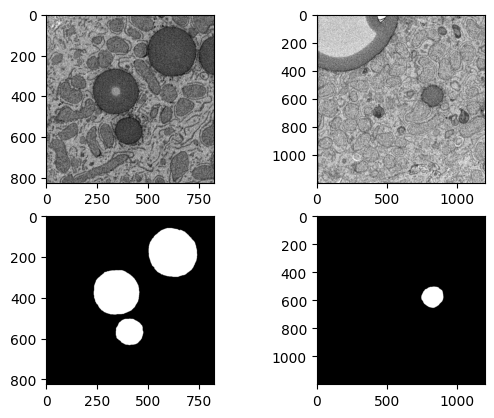

In [25]:
show_image_pairs(0, 500)

In [26]:
# save values in json file
def save_as_json(file_list, file_name):
    myfile = open( file_name + ".json", "w")
    json.dump(file_list, myfile, indent=6)
    myfile.close()

# calculate normalized mutual information of image pairs
def get_nmi_values(image_file_list, mask_file_list):
    nmi_img = []
    nmi_mask = []
    for i in range(len(image_file_list)-1):
        nmi_img.append( calculate_nmi(image_file_list[i], image_file_list[i+1]) )
        nmi_mask.append( calculate_nmi(mask_file_list[i], mask_file_list[i+1]) )

    # save nmi_values list in json file
    nmi_list = {"images": nmi_img,
                        "masks": nmi_mask}
    save_as_json(nmi_list, "nmi_img_mask_list")



In [ ]:
get_nmi_values(image_file_list, mask_file_list)

In [27]:
# load saved nmi_values list
def load_json_file(file_name):
    myfile = open(file_name + ".json")
    loaded_file = json.load(myfile)
    return loaded_file


In [28]:
# load the saved nmi_values json files and save it in nmi_list
nmi_list = load_json_file("json_files/nmi_img_mask_list")

nmi_img = nmi_list["images"]
nmi_mask = nmi_list["masks"]

print(f"First five nmi values for images: {nmi_img[0:5]}")
print(f"First five nmi values for masks: {nmi_mask[0:5]}")

First five nmi values for images: [1.0400136578746175, 1.059857613492082, 1.0485619151490775, 1.0483934915973405, 1.0469215545928423]
First five nmi values for masks: [1.6363943244255454, 1.6898369757829332, 1.5767065119493555, 1.6876057119064969, 1.7752790225443915]


### Summary of nmi values

In [27]:
df = pd.DataFrame(dict(
      image_id = [i for i in range(len(nmi_img))],
      nmi_img = nmi_img,
      nmi_mask = nmi_mask
  ))
fig = px.line(df, x="image_id", y=["nmi_img", "nmi_mask"])
fig.show()

## Make image stacks



In [34]:

def split_data_into_stacks(image_file_list, mask_file_list, values_list, threshold=2.1):
    image_stacks = []
    start = 0
    for i in range(len(image_file_list)-1):
        val = values_list[i]
        if val < threshold:
            image_stacks.append([start, i+1])
            start = i+1

    image_stacks.append([start, len(image_file_list)])
    return image_stacks


In [35]:
threshold = 2.1 # subject to change
image_stacks = split_data_into_stacks(image_file_list, mask_file_list, nmi_img, threshold)


In [8]:
# load saved image_stacks list
image_stacks = load_json_file("json_files/image_stacks")
print(f"Length of image_stacks: {len(image_stacks)}")


Length of image_stacks: 20


In [45]:
image_stacks

[[0, 6],
 [6, 10],
 [10, 60],
 [60, 85],
 [85, 88],
 [88, 148],
 [148, 337],
 [337, 451],
 [451, 472],
 [472, 502],
 [502, 652],
 [652, 719],
 [719, 824],
 [824, 1109],
 [1109, 1383],
 [1383, 1778],
 [1778, 1863],
 [1863, 2023],
 [2023, 2036],
 [2036, 2341]]

In [9]:
# get clean split according to image_stacks
def get_split_point(image_stacks, size, i):
    start, end = image_stacks[i]
    while(size < start or size > end):
        i += 1
        start, end = image_stacks[i]

    split = 0

    if size == end:
        split = end
    else:
        split = start

    return split, i


# split the data into training and test sests
def split_data(image_file_list, mask_file_list, image_stacks, test_ratio, val_ratio):
    test_size = math.floor(len(image_file_list)*test_ratio) # test size is set to be x% of the dataset
    val_size = math.floor(len(image_file_list)*val_ratio) # validation size is set to be y% of the dataset
    columns = ['images', 'masks']
    i = 0

    # make first split for testing
    split_test, i = get_split_point(image_stacks, test_size, i)
    test_images = image_file_list[0:split_test]
    test_masks = mask_file_list[0:split_test]
    test_df = pd.DataFrame(zip(test_images, test_masks), columns=columns)

    # make second split for validation
    split_val, i = get_split_point(image_stacks, val_size+split_test, i)
    val_images = image_file_list[split_test:split_val]
    val_masks = mask_file_list[split_test:split_val]
    val_df = pd.DataFrame(zip(val_images, val_masks), columns=columns)

    # make the rest for training
    train_images = image_file_list[split_val:]
    train_masks = mask_file_list[split_val:]
    train_df = pd.DataFrame(zip(train_images, train_masks), columns=columns)

    return train_df, val_df, test_df



In [15]:
test_ratio = 0.15 # test size is set to be 15% of the dataset
val_ratio = 0.15 # val size is set to be 15% of the dataset
train_df, val_df, test_df = split_data(image_file_list, mask_file_list, image_stacks, test_ratio, val_ratio)

print(f"Number of images in training set: {len(train_df['images'])}")
print(f"Number of masks in training set: {len(train_df['masks'])}")

print(f"Number of images in validation set: {len(val_df['images'])}")
print(f"Number of masks in validation set: {len(val_df['masks'])}")

print(f"Number of images in test set: {len(test_df['images'])}")
print(f"Number of masks in test set: {len(test_df['masks'])}")

Number of images in training set: 1622
Number of masks in training set: 1622
Number of images in validation set: 382
Number of masks in validation set: 382
Number of images in test set: 337
Number of masks in test set: 337


In [16]:
train_df.head()

,images,masks
0,data/images/56400789.jpg,data/masks/56400789.png
1,data/images/56400790.jpg,data/masks/56400790.png
2,data/images/56400791.jpg,data/masks/56400791.png
3,data/images/56400792.jpg,data/masks/56400792.png
4,data/images/56400793.jpg,data/masks/56400793.png


In [79]:
test_df.head()

,images,masks
0,data/images/50494616.jpg,data/masks/50494616.png
1,data/images/50494617.jpg,data/masks/50494617.png
2,data/images/50494618.jpg,data/masks/50494618.png
3,data/images/50494619.jpg,data/masks/50494619.png
4,data/images/50494620.jpg,data/masks/50494620.png


In [17]:
# Drop masks column in test_df
test_df = test_df.drop(columns=["masks"])
test_df.head()

,images
0,data/images/50494616.jpg
1,data/images/50494617.jpg
2,data/images/50494618.jpg
3,data/images/50494619.jpg
4,data/images/50494620.jpg


In [18]:
# save train_df and test_df
train_df.to_pickle("/content/drive/MyDrive/I2K_workshop/data/train_df.pkl")
val_df.to_pickle("/content/drive/MyDrive/I2K_workshop/data/val_df.pkl")
test_df.to_pickle("/content/drive/MyDrive/I2K_workshop/data/test_df.pkl")
